In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit
from cmath import sqrt
import glob


# Cargado de datos 

In [2]:
file_list = sorted(glob.glob("09h_50m_25s/*.pkl"))

def extract_data(file):
    d = pd.read_pickle(file) 
    return {
        'frequencies': d['frequency_Hz'],
        'r_mean': np.abs(d['R_V_mean']),
        'phases': d['Theta_deg_mean'],
        'x_mean': np.real(d['X_V_mean']),
        'y_mean': np.real(d['Y_V_mean']),
        'r_std': d['R_V_std'],
        'x_std': d['X_V_std'],
        'y_std': d['Y_V_std']
    }

df = pd.DataFrame([extract_data(f) for f in file_list])

freq = np.array(df['frequencies'])  
V_meas = np.array(df['r_mean'])

# Esto es para los errores. Luego tiene mas sentido igual. 
V_std = np.array(df['r_std'])
V_onepercent = 0.01 * V_meas

# Parámetros y derivación teórico 

In [3]:
V_source = 1 / (2 * np.sqrt(2)) # 1Vpp a RMS. 

fs = 50096.3  #Resonancia 

fp = 50284.5 #Anti resonancia 

Rs = 10000 #Resistencia de medida

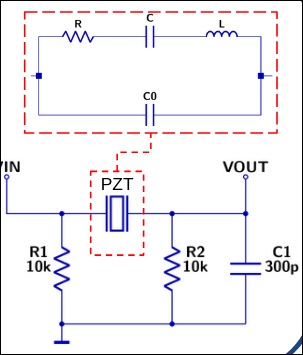

Voy a derivar este circuito teóricamente. Notar que enrealidad para el ajuste solo voy a usar la función de $r$. O sea, del valor absoluto de las medidas que tomamos, y NO voy a considerar C1. Eso solo lo voy a considerar para el ploteo para corregir la fase. No forma parte del análisis teórico esto.

Voy a calcular primero la impedancia del cristal, que en el código la llamo $Z_{xtal}$.

Para esto conviene definir la rama de arriba del piezo (se le llama motional branch no se por que) como $Z_m$

$$
Z_m = R + \frac{1}{i \omega C} + i \omega L \qquad Z_{C_0} = \frac{1}{i \omega C_0}
$$
$$

Z_{xtal} = Z_m \parallel Z_{C_0} = \frac{Z_m \cdot Z_{C_0}}{Z_m + Z_{C_0}}

$$

Finalmente, la función de transferencia va a ser solamente el voltaje que cae en $R_2$ dividido el voltaje de entrada... 

$$
H(\omega)=V_{\text{out}}/V_{\text{fuente}} = \frac{R_2}{R_2 + Z_{xtal}} \iff V_{out} = V_{fuente} \cdot \frac{R_2}{R_2 + Z_{xtal}}
$$

Despues ajusto con el valor absoluto de esto. 

Ahora, la resonancia sucede cuando la parte imaginaria de la señal es 0. Para que esto pase la rama de arriba, a la que le puse z_m tiene que tener parte imaginaria nula. O sea 


$$

\omega_s C = - \omega_s L \iff \omega_s^2 = \frac{1}{L \cdot C}

$$

Luego, la anti resonancia se produce cuando la impedancia del circuito tiende a infinito, (O sea, la admitancia tiende a 0)


$$

Y_{xtal} = Y_m + Y_{C_0}=\frac{1}{i(\omega_p L - \frac{1}{\omega_p C})} + i \omega_p C_0 =0 
$$


simplificando da que 

$$

\omega_p^2 \cdot L \cdot C -1 = \frac{C}{C_0}
$$

usando el otro vinculo 

$$

\frac{\omega_p^2}{\omega_s^2}-1 = \frac{C}{C_0} \iff \frac{f_p^2}{f_s^2}-1 = \frac{C}{C_0}

$$

In [4]:
ratio = (fp/fs)**2 - 1 #C1/C0

# Modelo y ajuste

In [5]:
def V_model(f, R1, C0):

    # Usamos las relaciones 

    C = ratio * C0
    L = 1.0 / ((2 * np.pi * fs)**2 * C)

    
    # modelamos el circuito especificamente 
    w = 2 * np.pi * f

    Z_m = R1 + 1j*(w*L - 1.0/(w*C))

    Z_C0 = 1.0 / (1j * w * C0)

    Z_xtal = (Z_m * Z_C0) / (Z_m + Z_C0)
    
    # Voltage divider equation
    return V_source * Rs / np.abs(Rs + Z_xtal) #Innecesario tomar el valor absoluto de todo
# Notar que esto es V_out. O sea lo medido. No la transferencia directamente (ademas no ajustas eso lol)

In [14]:
ERRORES = True 

V_err =0.6 * V_onepercent #Acá defino errores, cualquiera otra cosa que quieran probar para los mismos cambiar aquí

In [15]:
# La seed esta viene de hacer esto mismo sin errores
p0 = [9489.7, 2.1589e-12]

print("Ajustanding...")


if ERRORES:
    popt, pcov = curve_fit(V_model, freq, V_meas, p0=p0, sigma=V_err, absolute_sigma=True)
else:
    popt, pcov = curve_fit(V_model, freq, V_meas, p0=p0)

R1_fit, C0_fit = popt
R1_err, C0_err = np.sqrt(np.diag(pcov))

# Sacamos los parámetros dependientes

C_fit = ratio * C0_fit
C_err = ratio * C0_err  # Propagación de errores de C

ws = 2 * np.pi * fs
L_fit = 1.0 / (ws**2 * C_fit)
L_err = L_fit * (C_err / C_fit)  # Error de L, se transfiere proporcionalmente al error de C

Q_fit = (2 * np.pi * fs * L_fit) / R1_fit

print("\n=== Resultados del ajuste ===")
print(f"R1 = {R1_fit:.1f} +/- {R1_err:.1f} Ohms")
print(f"C = {C_fit*1e15:.3f} +/- {C_err*1e15:.3f} fF")
print(f"L = {L_fit:.2f} +/- {L_err:.2f} H")
print(f"C0 = {C0_fit*1e12:.4f} +/- {C0_err*1e12:.4f} pF")
print(f"Q  = {Q_fit:.0f}")

Ajustanding...

=== Resultados del ajuste ===
R1 = 9490.1 +/- 11.3 Ohms
C = 16.251 +/- 0.004 fF
L = 621.09 +/- 0.14 H
C0 = 2.1588 +/- 0.0005 pF
Q  = 20600


Chi^2         = 736.44
Degrees of freedom (nu) = 744
Reduced Chi^2 = 0.9898


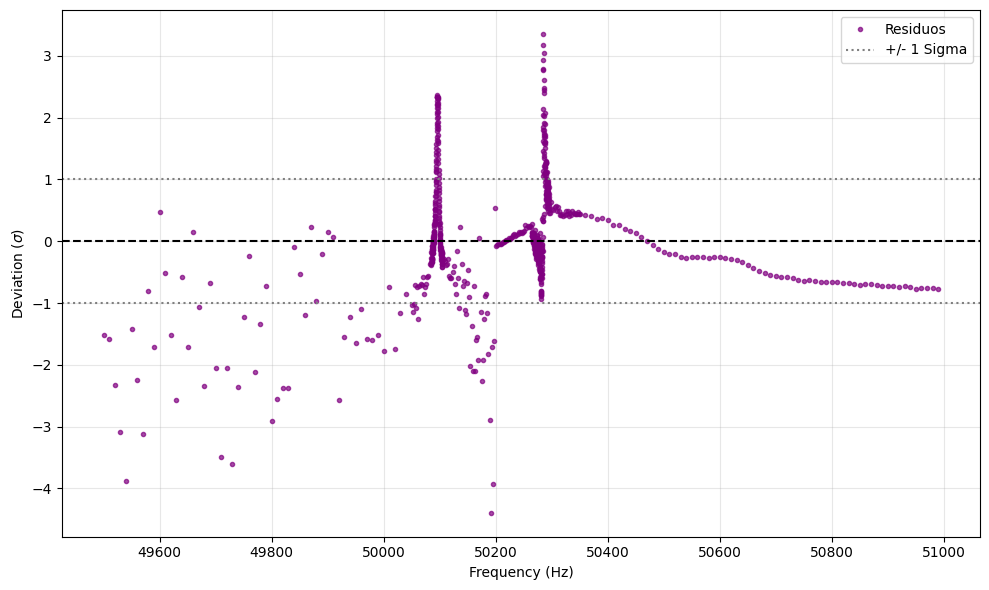

In [16]:
#Residuos 

V_pred = V_model(freq, R1_fit, C0_fit)

residuals = V_meas - V_pred
normed_residuals = residuals / V_err #Estoy calculando los residuos normalizados, es lo mismo solo q divido por el error para ver cuantas sigmas me estoy desviando del modelo 

chi2 = np.sum(normed_residuals**2)

dof = len(freq) - len(popt)

reduced_chi2 = chi2 / dof

print(f"Chi^2         = {chi2:.2f}")
print(f"Degrees of freedom (nu) = {dof}")
print(f"Reduced Chi^2 = {reduced_chi2:.4f}")


plt.figure(figsize=(10, 6))

plt.plot(freq, normed_residuals, '.', color='purple', alpha=0.7, label=r'Residuos')
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'+/- 1 Sigma')
plt.axhline(-1, color='gray', linestyle=':')

plt.xlabel(r'Frequency (Hz)')
plt.ylabel(r'Deviation ($\sigma$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

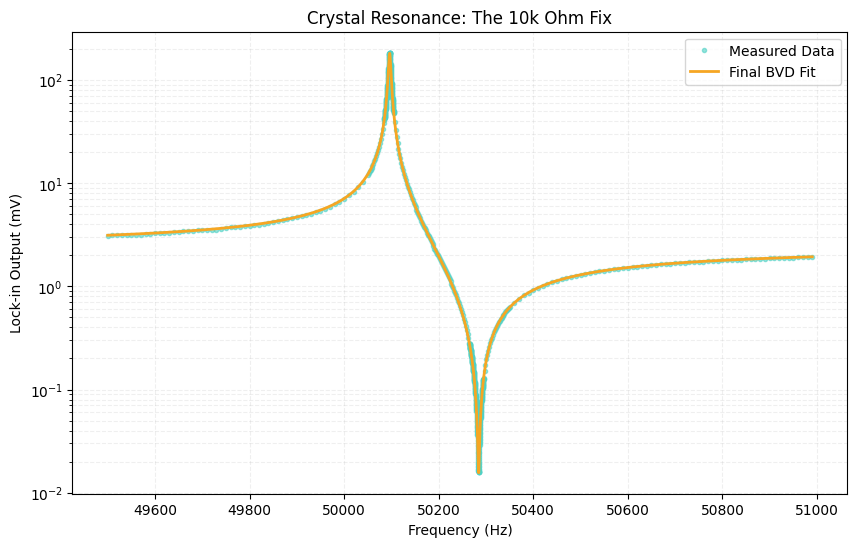

In [9]:
#Ploteo rapido 

plt.figure(figsize=(10, 6))
plt.semilogy(freq, V_meas * 1000, 'o', markersize=3, label='Measured Data', alpha=0.6, color='#4fd1c5')
plt.semilogy(freq, V_model(freq, R1_fit, C0_fit) * 1000, '-', linewidth=2, label='Final BVD Fit', color='#f6a623')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Lock-in Output (mV)')
plt.title('Crystal Resonance: The 10k Ohm Fix')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.show()